# NB05: Taxonomic Bias Analysis

Compare taxonomic composition of cultured vs MAG cohorts to determine whether
functional bias is driven by taxonomic sampling gaps (phylum-level absence)
or within-lineage cultivation selection.

**Requires**: `data/pangenome_subsurface_mag_metadata.tsv`, `data/cultured_genome_metadata.tsv`,
`data/ko_cultivation_coverage_full.tsv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from berdl_notebook_utils.setup_spark_session import get_spark_session

spark = get_spark_session()
DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 1. Load Metadata

In [2]:
cult_meta = pd.read_csv(DATA_DIR / 'cultured_genome_metadata.tsv', sep='\t')
mag_meta = pd.read_csv(DATA_DIR / 'pangenome_subsurface_mag_metadata.tsv', sep='\t')

print(f'Cultured: {len(cult_meta)} genomes')
print(f'MAGs: {len(mag_meta)} genomes')

# Parse taxonomy to phylum level for both
# Cultured: taxon_name from ENIGMA Genome Depot
# MAGs: gtdb_taxonomy from kbase_ke_pangenome (format: d__Bacteria;p__Proteobacteria;...)

print(f'\nCultured taxonomy sample:')
print(cult_meta['taxon_name'].head(10).to_list())
print(f'\nMAG taxonomy sample:')
print(mag_meta['gtdb_taxonomy'].dropna().head(10).to_list())

Cultured: 3110 genomes
MAGs: 2425 genomes

Cultured taxonomy sample:
['Rhodanobacter denitrificans', 'Acidovorax sp. GW101-3H11', 'Agrobacterium fabrum str. C58', 'Shewanella sp. ANA-3', 'Azospirillum baldaniorum', 'Paraburkholderia phytofirmans PsJN', 'Bifidobacterium breve UCC2003', 'Bacteroides thetaiotaomicron VPI-5482', 'Paraburkholderia caledonica', 'Burkholderiaceae bacterium']

MAG taxonomy sample:
['d__Bacteria;p__Bacteroidota;c__Ignavibacteria;o__Ignavibacteriales;f__Melioribacteraceae;g__GCA-2746605;s__GCA-2746605 sp016713565', 'd__Bacteria;p__Methylomirabilota;c__Methylomirabilia;o__Rokubacteriales;f__CSP1-6;g__UBA12499;s__UBA12499 sp016177555', 'd__Bacteria;p__Desulfobacterota_B;c__Binatia;o__UBA9968;f__UBA9968;g__JACPFE01;s__JACPFE01 sp016183145', 'd__Bacteria;p__Methylomirabilota;c__Methylomirabilia;o__Methylomirabilales;f__2-02-FULL-66-22;g__2-02-FULL-66-22;s__2-02-FULL-66-22 sp016180655', 'd__Archaea;p__Nanoarchaeota;c__Nanoarchaeia;o__Pacearchaeales;f__GW2011-AR1;g__J

## 2. Phylum-Level Comparison

In [3]:
# Replace the broken extract_phylum() with a real GTDB-backed lookup.
# MAGs: parse the gtdb_taxonomy string (works fine).
# Cultured: use GCF/GCA accession against gtdb_taxonomy_r214v1; fall back to genus-mode lookup.

def parse_gtdb_phylum(tax_str):
    if pd.isna(tax_str):
        return 'Unknown'
    for part in str(tax_str).split(';'):
        if part.strip().startswith('p__'):
            return part.strip().replace('p__', '') or 'Unclassified'
    return 'Unknown'

mag_meta['phylum'] = mag_meta['gtdb_taxonomy'].apply(parse_gtdb_phylum)

def extract_assembly_acc(ext_id):
    if pd.isna(ext_id):
        return None
    s = str(ext_id)
    if s.startswith('NCBI:'):
        s = s[5:]
    if s.startswith('GCF_'):
        return f'RS_{s}'
    if s.startswith('GCA_'):
        return f'GB_{s}'
    return None

cult_meta['pangenome_id'] = cult_meta['external_id'].apply(extract_assembly_acc)
pids = sorted(set(cult_meta['pangenome_id'].dropna()))
print(f'Looking up GTDB phylum for {len(pids)} cultured accessions...')

acc_lookup = pd.DataFrame(columns=['pangenome_id', 'gtdb_phylum', 'gtdb_genus'])
if pids:
    pid_str = ','.join([f"'{p}'" for p in pids])
    acc_lookup = spark.sql(f"""
        SELECT genome_id AS pangenome_id, phylum AS gtdb_phylum, genus AS gtdb_genus
        FROM kbase_ke_pangenome.gtdb_taxonomy_r214v1
        WHERE genome_id IN ({pid_str})
    """).toPandas()
    acc_lookup['gtdb_phylum'] = acc_lookup['gtdb_phylum'].str.replace('p__', '', regex=False)
    acc_lookup['gtdb_genus']  = acc_lookup['gtdb_genus'].str.replace('g__', '', regex=False)

cult_meta = cult_meta.merge(acc_lookup, on='pangenome_id', how='left')
print(f'  Accession-matched: {cult_meta["gtdb_phylum"].notna().sum()}/{len(cult_meta)}')

# Genus -> phylum mode from GTDB R214v1 (fallback for genomes without accession match)
genus_phyla = spark.sql("""
    SELECT genus, phylum, COUNT(*) AS n
    FROM kbase_ke_pangenome.gtdb_taxonomy_r214v1
    WHERE genus IS NOT NULL AND genus != 'g__'
    GROUP BY genus, phylum
""").toPandas()
genus_phyla['genus']  = genus_phyla['genus'].str.replace('g__', '', regex=False)
genus_phyla['phylum'] = genus_phyla['phylum'].str.replace('p__', '', regex=False)
genus_to_phylum = (genus_phyla.sort_values('n', ascending=False)
                              .drop_duplicates('genus')
                              .set_index('genus')['phylum']
                              .to_dict())

NON_GENUS_TOKENS = {'environmental', 'Unknown', 'unclassified', 'bacterium',
                    'Candidatus', 'NULL', 'uncultured'}

def first_token(s):
    if pd.isna(s):
        return None
    parts = str(s).strip().split()
    if not parts:
        return None
    t = parts[0]
    if t in NON_GENUS_TOKENS:
        return None
    return t

cult_meta['enigma_genus'] = cult_meta['taxon_name'].apply(first_token)
genus_phyla_resolved = cult_meta['enigma_genus'].map(genus_to_phylum)
cult_meta['phylum'] = cult_meta['gtdb_phylum'].fillna(genus_phyla_resolved).fillna('Unclassified')

acc_n      = cult_meta['gtdb_phylum'].notna().sum()
genus_n    = (cult_meta['gtdb_phylum'].isna() & genus_phyla_resolved.notna()).sum()
unclass_n  = (cult_meta['phylum'] == 'Unclassified').sum()
print(f'Cultured phylum coverage:')
print(f'  via accession: {acc_n}')
print(f'  via genus-mode: {genus_n}')
print(f'  unclassified : {unclass_n}')

cult_phyla = cult_meta['phylum'].value_counts().rename('cultured')
mag_phyla  = mag_meta['phylum'].value_counts().rename('mag')
phyla = pd.DataFrame({'cultured': cult_phyla, 'mag': mag_phyla}).fillna(0).astype(int)
phyla['cult_frac'] = phyla['cultured'] / phyla['cultured'].sum()
phyla['mag_frac']  = phyla['mag']      / phyla['mag'].sum()
phyla = phyla.sort_values(['cultured', 'mag'], ascending=[False, False])

print(f'\nPhylum distribution (top 20 by cultured count):')
print(phyla.head(20).to_string())

cult_only_phyla = phyla[(phyla['cultured'] > 0) & (phyla['mag'] == 0)].index.tolist()
mag_only_phyla  = phyla[(phyla['cultured'] == 0) & (phyla['mag'] > 0)].index.tolist()
print(f'\nPhyla only in cultured (n={len(cult_only_phyla)}): {cult_only_phyla[:15]}')
print(f'Phyla only in MAGs (n={len(mag_only_phyla)}): {mag_only_phyla[:15]}')

# Save for downstream use
phyla.to_csv(DATA_DIR / 'phylum_composition.tsv', sep='\t')

Looking up GTDB phylum for 417 cultured accessions...


  Accession-matched: 153/3110


Cultured phylum coverage:
  via accession: 153
  via genus-mode: 2309
  unclassified : 648

Phylum distribution (top 20 by cultured count):
                    cultured  mag  cult_frac  mag_frac
phylum                                                
Pseudomonadota          2016  416   0.648232  0.171546
Unclassified             648    0   0.208360  0.000000
Actinomycetota           168   40   0.054019  0.016495
Bacteroidota             140  197   0.045016  0.081237
Bacillota                127   14   0.040836  0.005773
Desulfobacterota           3   56   0.000965  0.023093
Methanobacteriota          2    6   0.000643  0.002474
Verrucomicrobiota          1   32   0.000322  0.013196
Cyanobacteriota            1   16   0.000322  0.006598
Thermoproteota             1   12   0.000322  0.004948
Bacillota_A                1    7   0.000322  0.002887
Halobacteriota             1    4   0.000322  0.001649
Deinococcota               1    3   0.000322  0.001237
Patescibacteria            0  963  

## 3. Relative Abundance Comparison Plot

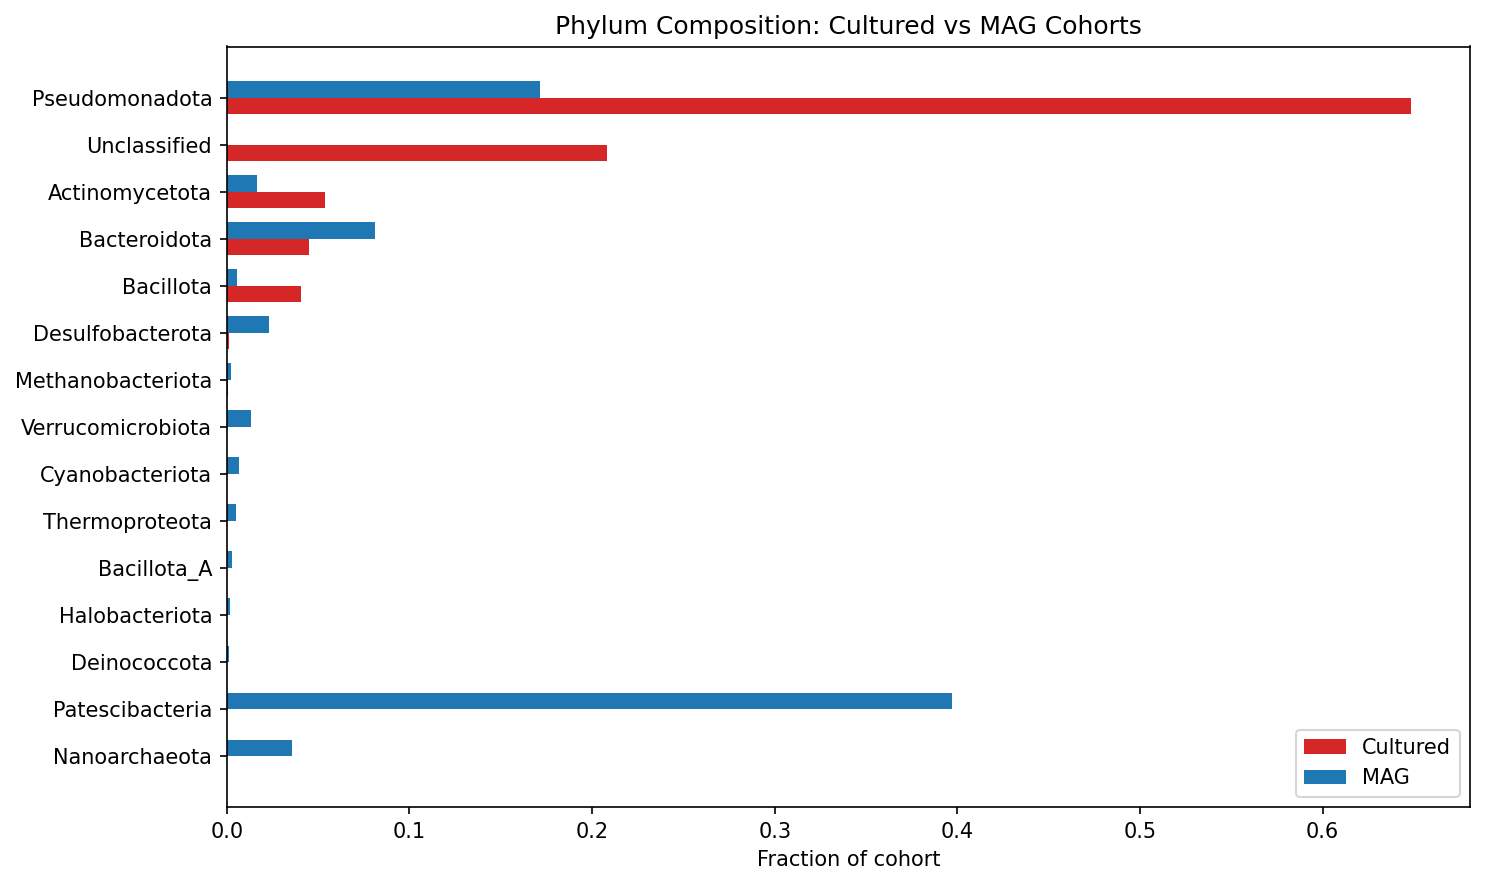

In [4]:
# Top phyla bar chart
top_phyla = phyla.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(top_phyla))
w = 0.35
ax.barh(x + w/2, top_phyla['cult_frac'], w, label='Cultured', color='#d62728')
ax.barh(x - w/2, top_phyla['mag_frac'], w, label='MAG', color='#1f77b4')
ax.set_yticks(x)
ax.set_yticklabels(top_phyla.index)
ax.set_xlabel('Fraction of cohort')
ax.set_title('Phylum Composition: Cultured vs MAG Cohorts')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / 'phylum_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Genome Size Comparison

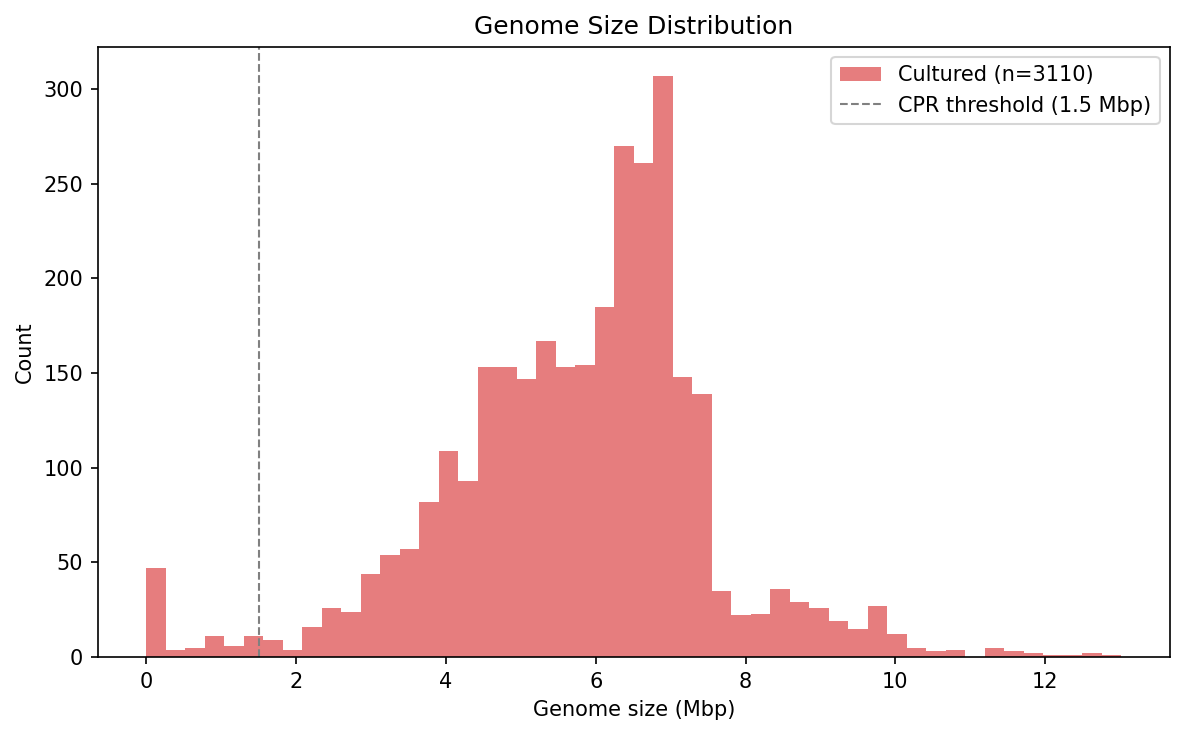

Cultured genomes < 1.5 Mbp (CPR-size): 80/3110 (2.6%)


In [5]:
if 'genome_size' in cult_meta.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    cult_sizes = cult_meta['genome_size'].dropna() / 1e6  # Mbp
    ax.hist(cult_sizes, bins=50, alpha=0.6, label=f'Cultured (n={len(cult_sizes)})', color='#d62728')
    
    # MAG sizes would need to be computed from FASTA files or bin metadata
    # For now, plot cultured only and note the gap
    ax.set_xlabel('Genome size (Mbp)')
    ax.set_ylabel('Count')
    ax.set_title('Genome Size Distribution')
    ax.legend()
    ax.axvline(1.5, ls='--', c='gray', lw=1, label='CPR threshold (1.5 Mbp)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'genome_size_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    small_genomes = cult_sizes[cult_sizes < 1.5]
    print(f'Cultured genomes < 1.5 Mbp (CPR-size): {len(small_genomes)}/{len(cult_sizes)} ({len(small_genomes)/len(cult_sizes)*100:.1f}%)')

## 5. Functional Bias × Taxonomy

In [6]:
# For MAG-only phyla, what KOs are they carrying that the cultured collection misses?
mag_ko = pd.read_csv(DATA_DIR / 'mag_ko_profiles.tsv', sep='\t')
cult_ko = pd.read_csv(DATA_DIR / 'cultured_ko_profiles.tsv', sep='\t')
coverage = pd.read_csv(DATA_DIR / 'ko_cultivation_coverage_full.tsv', sep='\t', index_col=0)

# KOs from MAG-only phyla
mag_only_phyla_genomes = mag_meta[mag_meta['phylum'].isin(mag_only_phyla)]['genome_id']
if len(mag_only_phyla_genomes) > 0:
    mag_only_kos = mag_ko[mag_ko['genome_id'].isin(mag_only_phyla_genomes)]['ko_id'].unique()
    exclusive_kos = set(mag_only_kos) - set(cult_ko['ko_id'].unique())
    print(f'MAG-only phyla contribute {len(mag_only_phyla_genomes)} genomes')
    print(f'  {len(mag_only_kos)} KOs total, {len(exclusive_kos)} exclusive to MAGs')
else:
    print('No MAG-only phyla detected (taxonomy parsing may need adjustment)')

MAG-only phyla contribute 1622 genomes
  2982 KOs total, 281 exclusive to MAGs
